In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
df = pd.read_csv("/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
print(df["Exited"].value_counts(normalize=True) * 100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


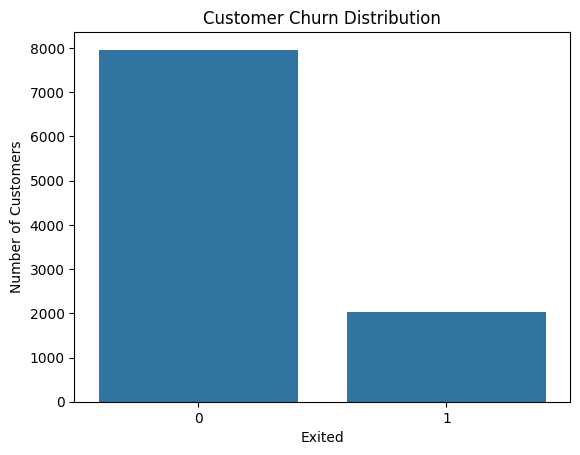

In [ ]:
sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [ ]:
X = X.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [ ]:
X = pd.get_dummies(
    X,
    columns=["Geography", "Gender"],
    drop_first=True
)


In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
print(X.dtypes)

CreditScore            int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Geography_Germany       bool
Geography_Spain         bool
Gender_Male             bool
dtype: object


In [ ]:
X = X.astype(int)

print(X.dtypes)

CreditScore          int64
Age                  int64
Tenure               int64
Balance              int64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary      int64
Geography_Germany    int64
Geography_Spain      int64
Gender_Male          int64
dtype: object


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7966 - loss: 0.4727 - val_accuracy: 0.8331 - val_loss: 0.4193
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8209 - loss: 0.4244 - val_accuracy: 0.8469 - val_loss: 0.3934
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8327 - loss: 0.4016 - val_accuracy: 0.8594 - val_loss: 0.3682
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8391 - loss: 0.3865 - val_accuracy: 0.8675 - val_loss: 0.3537
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8447 - loss: 0.3758 - val_accuracy: 0.8631 - val_loss: 0.3477
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8439 - loss: 0.3704 - val_accuracy: 0.8656 - val_loss: 0.3432
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8502 - loss: 0.3617 - val_accuracy: 0.8669 - val_loss: 0.3390
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8534 - loss: 0.3597 - val_accuracy: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 85.65%


In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:
def build_model(hp):

    model = keras.Sequential()

    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Number of hidden layers
    for i in range(hp.Int("num_layers", min_value=1, max_value=3)):

        model.add(
            layers.Dense(
                units=hp.Int(
                    f"units_{i}",
                    min_value=32,
                    max_value=128,
                    step=32
                ),
                activation="relu"
            )
        )

        model.add(
            layers.Dropout(
                hp.Float(
                    f"dropout_{i}",
                    min_value=0.0,
                    max_value=0.4,
                    step=0.1
                )
            )
        )

    # Output layer
    model.add(layers.Dense(1, activation="sigmoid"))

    # Learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.0001, 0.001, 0.01]
    )

    # Optimizer
    optimizer = hp.Choice(
        "optimizer",
        values=["adam", "rmsprop"]
    )

    if optimizer == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1,
    directory="keras_tuner",
    project_name="churn_model"
)

In [ ]:
tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Trial 15 Complete [00h 00m 21s]
val_accuracy: 0.8675000071525574

Best val_accuracy So Far: 0.8762500286102295
Total elapsed time: 00h 06m 00s


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print("----------------------")

for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

Best Hyperparameters:
----------------------
num_layers: 3
units_0: 32
dropout_0: 0.0
learning_rate: 0.01
optimizer: rmsprop
units_1: 64
dropout_1: 0.30000000000000004
units_2: 64
dropout_2: 0.2


In [ ]:
best_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.0),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

In [ ]:
best_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history_best = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8189 - loss: 0.4258 - val_accuracy: 0.8625 - val_loss: 0.3726
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8464 - loss: 0.3832 - val_accuracy: 0.8569 - val_loss: 0.4012
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8469 - loss: 0.3787 - val_accuracy: 0.8619 - val_loss: 0.3486
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8478 - loss: 0.3765 - val_accuracy: 0.8606 - val_loss: 0.3805
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8516 - loss: 0.3701 - val_accuracy: 0.8587 - val_loss: 0.3707
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8498 - loss: 0.3748 - val_accuracy: 0.8700 - val_loss: 0.3424
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8553 - loss: 0.3665 - val_accuracy: 0.8650 - val_loss: 0.3563
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8553 - loss: 0.3644 - val_acc

In [ ]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 85.85%


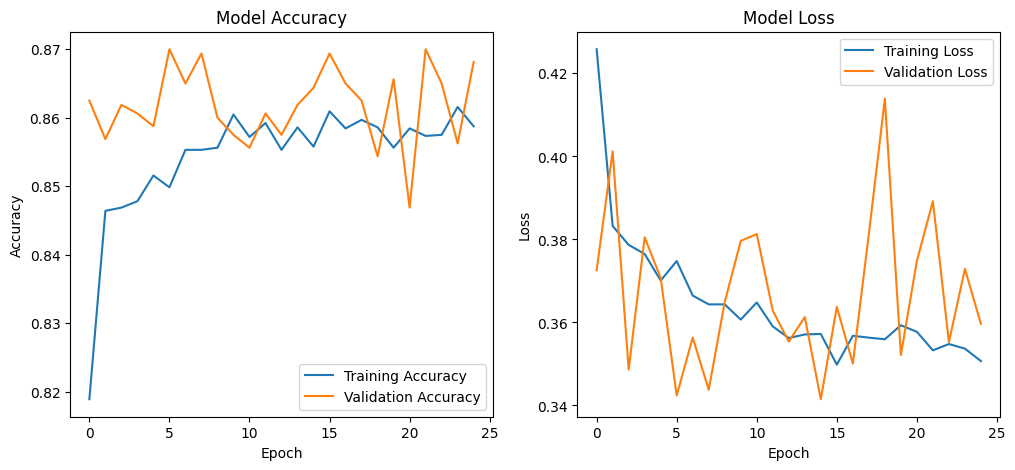

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_best.history["accuracy"], label="Training Accuracy")
plt.plot(history_best.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_best.history["loss"], label="Training Loss")
plt.plot(history_best.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
y_pred_prob = best_model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.41      0.54       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



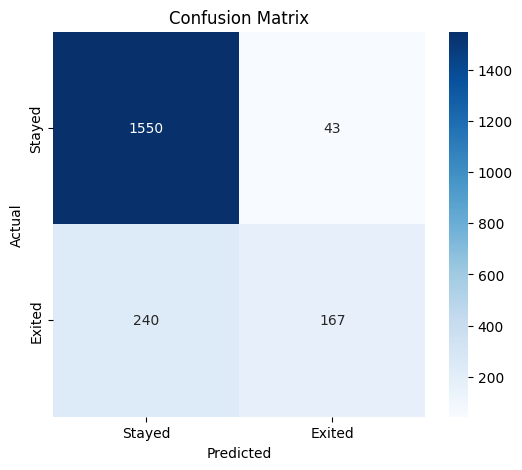

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Exited"],
    yticklabels=["Stayed", "Exited"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("========== Final Results ==========")
print(f"Baseline Accuracy: {test_accuracy * 100:.2f}%")
print(f"Best Model Accuracy: {test_accuracy * 100:.2f}%")
print()
print("Best Hyperparameters:")
print("Number of Layers: 3")
print("Layer 1 Units: 32")
print("Layer 1 Dropout: 0.0")
print("Layer 2 Units: 64")
print("Layer 2 Dropout: 0.3")
print("Layer 3 Units: 64")
print("Layer 3 Dropout: 0.2")
print("Learning Rate: 0.01")
print("Optimizer: RMSprop")

========== Final Results ==========
Baseline Accuracy: 85.85%
Best Model Accuracy: 85.85%

Best Hyperparameters:
Number of Layers: 3
Layer 1 Units: 32
Layer 1 Dropout: 0.0
Layer 2 Units: 64
Layer 2 Dropout: 0.3
Layer 3 Units: 64
Layer 3 Dropout: 0.2
Learning Rate: 0.01
Optimizer: RMSprop


In [ ]:
final_accuracy = test_accuracy

print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

Final Test Accuracy: 85.85%


In [ ]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")
print()

print("Best Hyperparameters:")
print(f"Number of Layers: {best_hps.get('num_layers')}")
print(f"Layer 1 Units: {best_hps.get('units_0')}")
print(f"Layer 1 Dropout: {best_hps.get('dropout_0')}")
print(f"Layer 2 Units: {best_hps.get('units_1')}")
print(f"Layer 2 Dropout: {best_hps.get('dropout_1')}")
print(f"Layer 3 Units: {best_hps.get('units_2')}")
print(f"Layer 3 Dropout: {best_hps.get('dropout_2')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Optimizer: {best_hps.get('optimizer')}")

FINAL MODEL RESULTS
Final Test Accuracy: 85.85%

Best Hyperparameters:
Number of Layers: 3
Layer 1 Units: 32
Layer 1 Dropout: 0.0
Layer 2 Units: 64
Layer 2 Dropout: 0.30000000000000004
Layer 3 Units: 64
Layer 3 Dropout: 0.2
Learning Rate: 0.01
Optimizer: rmsprop
